<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/SEMANA_5/TAREA3/Clasificaci%C3%B3n_usando_perceptron_Adaline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BILLETES


EDA

In [16]:

# ------------------------------------------------------------
# 1. Importación de librerías
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='deep', font_scale=1.1)

# ------------------------------------------------------------
# 2. Carga del dataset
# ------------------------------------------------------------
url = "https://raw.githubusercontent.com/MiguelAngeloTr/Aprendizaje_Automatico/refs/heads/main/SEMANA_5/TAREA3/data_billetes.csv"
billetes = pd.read_csv(url)

print("Dataset cargado correctamente.")
print(f"Filas: {billetes.shape[0]}  |  Columnas: {billetes.shape[1]}")
billetes.head()




Dataset cargado correctamente.
Filas: 1372  |  Columnas: 5


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [17]:


# ------------------------------------------------------------
# 3. Información general del dataset
# ------------------------------------------------------------
print("\nInformación general del DataFrame:")
billetes.info()

print("\nResumen estadístico de las variables numéricas:")
display(billetes.describe().T)

# ------------------------------------------------------------
# 4. Revisión de valores nulos y duplicados
# ------------------------------------------------------------
print("\nValores nulos por columna:")
print(billetes.isnull().sum())

print("\nRegistros duplicados:")
print(billetes.duplicated().sum())
print(billetes[billetes.duplicated()])



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Resumen estadístico de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000



Valores nulos por columna:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Registros duplicados:
24
     variance  skewness  curtosis  entropy  class
47    -0.7869    9.5663   -3.7867  -7.5034      0
139   -0.2062    9.2207   -3.7044  -6.8103      0
190    0.9297   -3.7971    4.6429  -0.2957      0
195   -1.8584    7.8860   -1.6643  -1.8384      0
226    0.5706   -0.0248    1.2421  -0.5621      0
268    0.9297   -3.7971    4.6429  -0.2957      0
284   -1.3000   10.2678   -2.9530  -5.8638      0
300    0.3292   -4.4552    4.5718  -0.9888      0
315    0.3292   -4.4552    4.5718  -0.9888      0
320    0.5195   -3.2633    3.0895  -0.9849      0
345   -1.8584    7.8860   -1.6643  -1.8384      0
351    0.5195   -3.2633    3.0895  -0.9849      0
352    0.3292   -4.4552    4.5718  -0.9888      0
404    0.3798    0.7098    0.7572  -0.4444      0
427   -1.3000   10.2678   -2.9530  -5.8638      0
436    0.3798    0.7098    0.7572  -0.4444      0
476    0.3798


Registros duplicados:
0
(1348, 5)


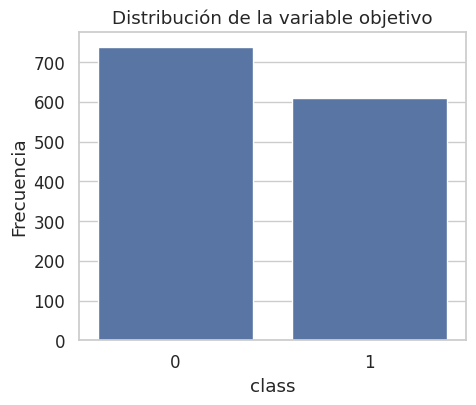

In [23]:
#Eliminar duplicados
billetes = billetes.drop_duplicates()
print("\nRegistros duplicados:")
print(billetes.duplicated().sum())

print(billetes.shape)
# ------------------------------------------------------------
# 5. Distribución de la variable objetivo
# ------------------------------------------------------------
# Se asume que la última columna corresponde a la variable objetivo
target_col = 'target_class' if 'target_class' in billetes.columns else billetes.columns[-1]

plt.figure(figsize=(5,4))
sns.countplot(data=billetes, x=target_col)
plt.title('Distribución de la variable objetivo')
plt.xlabel(target_col)
plt.ylabel('Frecuencia')
plt.show()


Se decide que el desbalanceo es leve y no requiere tecnicas de balanceo

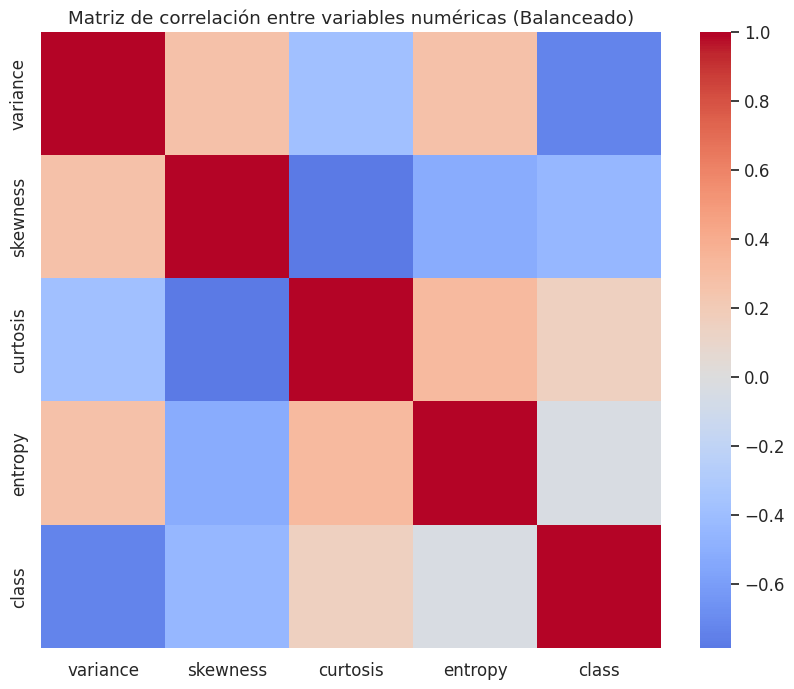

In [27]:

# ------------------------------------------------------------
# 6. Matriz de correlación
# ------------------------------------------------------------
plt.figure(figsize=(10,8))
corr = billetes.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables numéricas (Balanceado)')
plt.show()


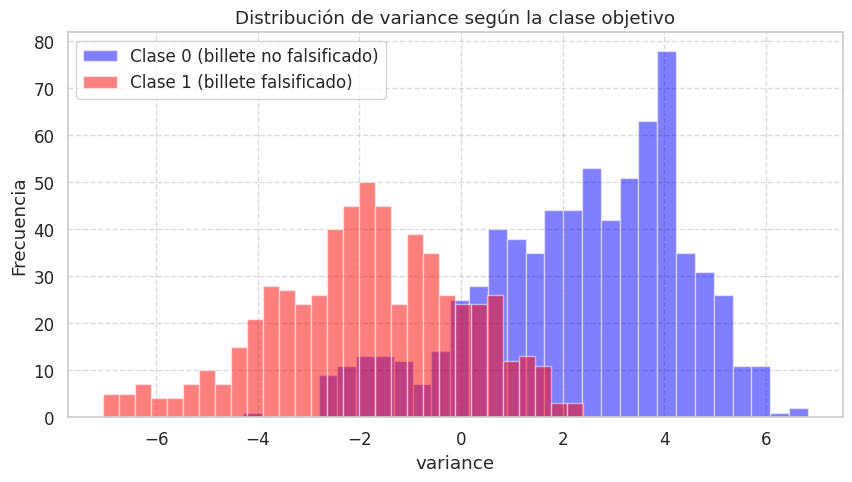

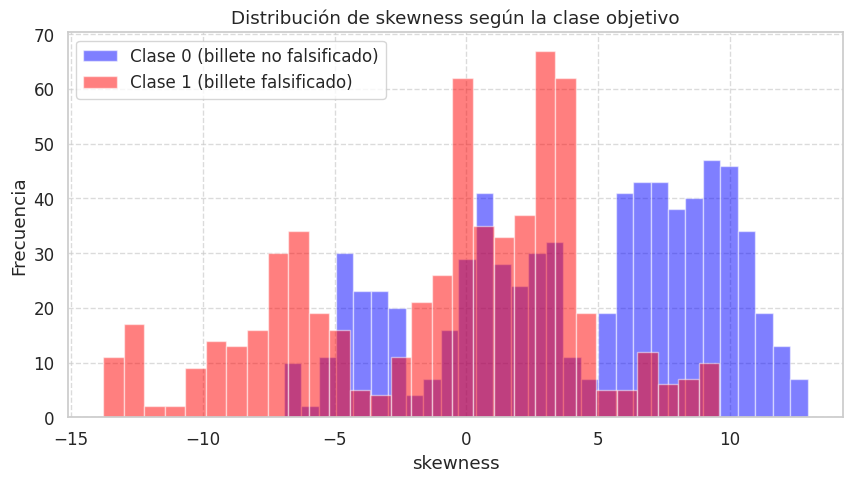

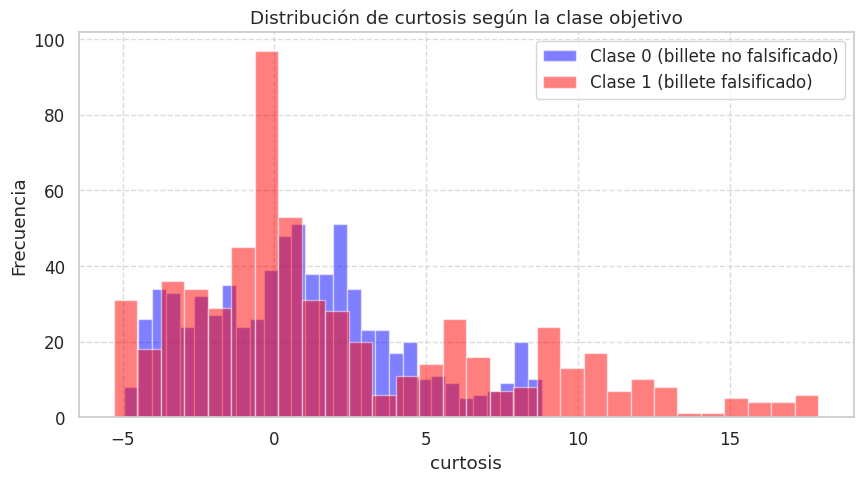

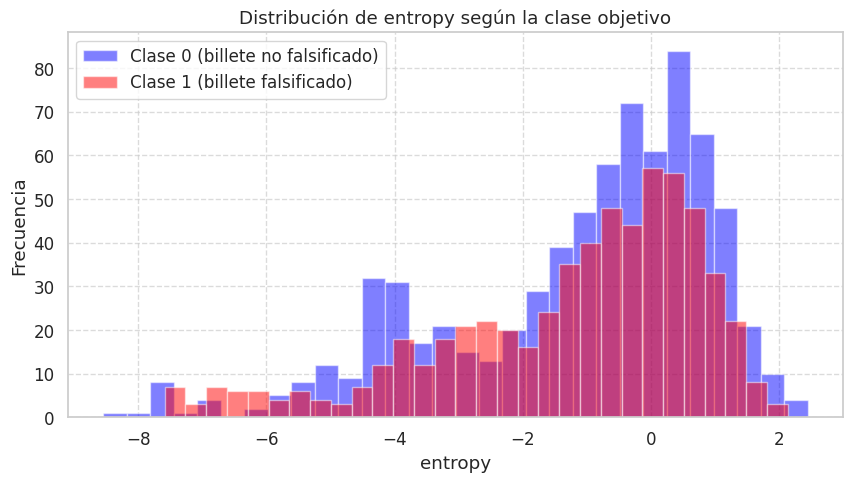

In [35]:
# -----------------------------------------
# COMPARACIÓN DE DISTRIBUCIONES POR CLASE
# -------------------------------------------

import matplotlib.pyplot as plt

# Identificar variable objetivo
target_col = 'target_class' if 'target_class' in billetes.columns else billetes.columns[-1]

# Definir características numéricas (todas menos la target)
features = [col for col in billetes.columns if col != target_col]

# Crear histogramas comparativos por clase
for feature in features:
    plt.figure(figsize=(10, 5))

    billetes[billetes[target_col] == 0][feature].plot(
        kind='hist', alpha=0.5, color='blue', bins=30, label='Clase 0 (billete no falsificado)')

    billetes[billetes[target_col] == 1][feature].plot(
        kind='hist', alpha=0.5, color='red', bins=30, label='Clase 1 (billete falsificado)')

    plt.title(f'Distribución de {feature} según la clase objetivo')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

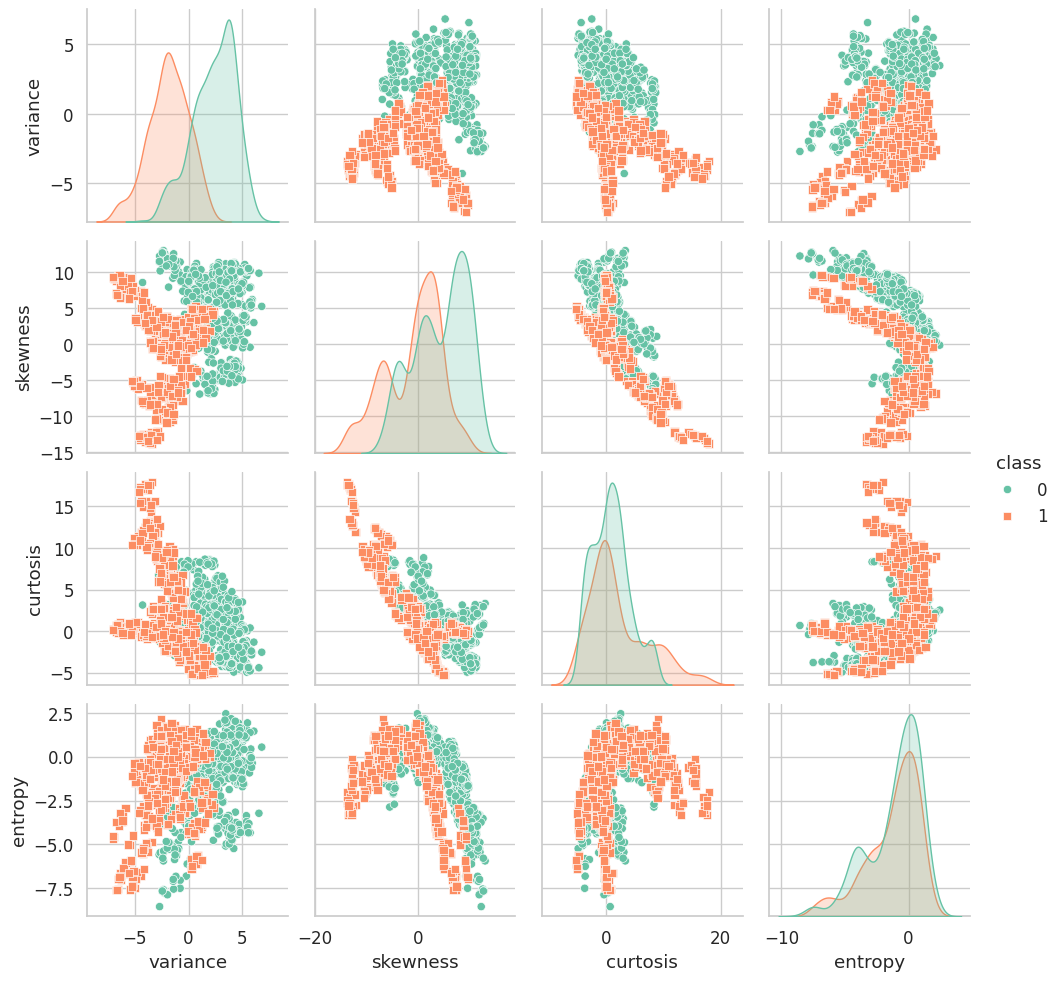

In [33]:

import seaborn as sns
sns.pairplot(billetes, hue="class", markers=["o", "s"], palette="Set2")

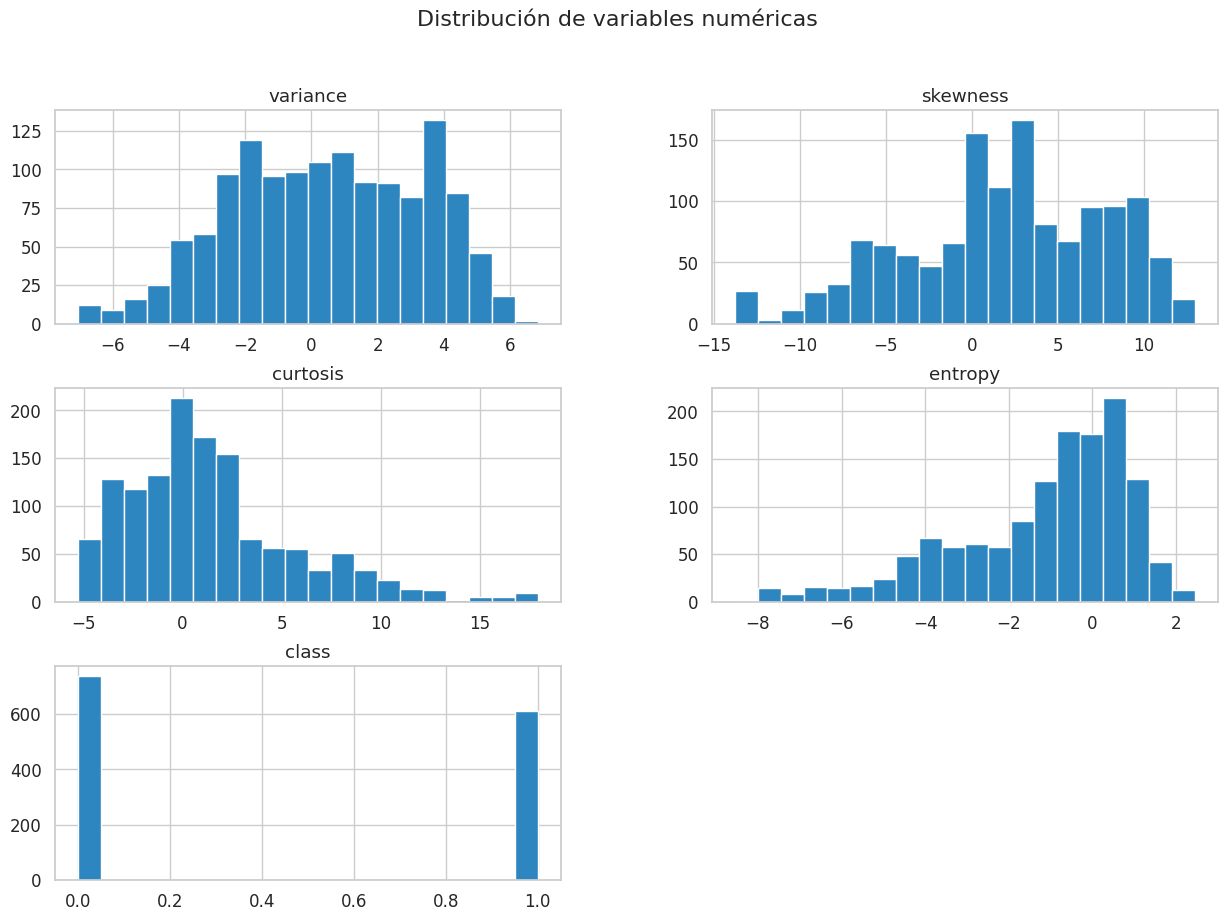

In [26]:


# ------------------------------------------------------------
# 7. Distribución de variables numéricas
# ------------------------------------------------------------
num_cols = billetes.select_dtypes(include=np.number).columns

billetes[num_cols].hist(bins=20, figsize=(15,10), color='#2E86C1')
plt.suptitle('Distribución de variables numéricas', fontsize=16)
plt.show()

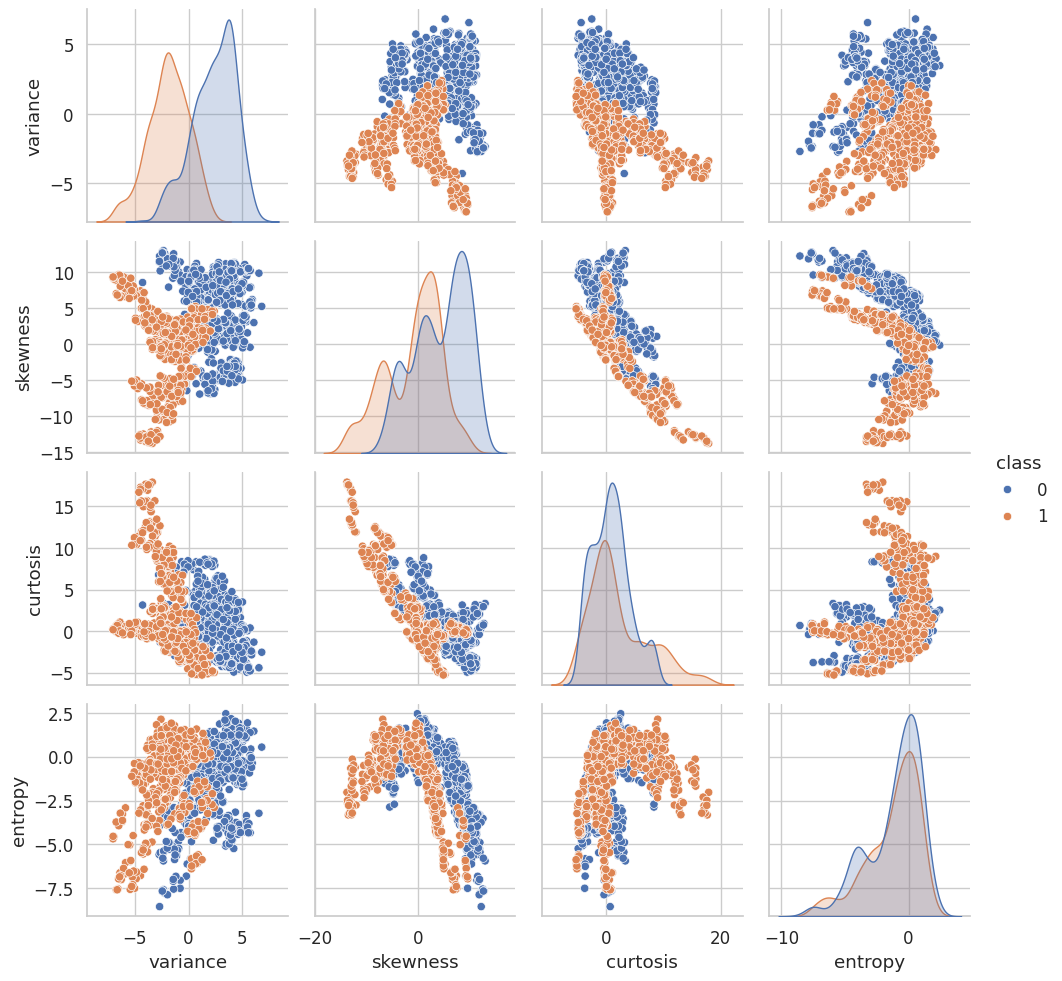

Las variables con una mejor separabilidad visual son variance y curtosis ya que se logra ver que los puntos azules y naranjas diferenciados y se nota una ligera frontera entre ellos

2. En función del ítem 1, seleccione las dos características y genere tanto la matriz de características
X como el vector de targets y

In [37]:
class AdalineGD(object):
    """ADAptive LInear NEuron classifier.

    Parámetros
    ------------
    |eta : float
      Tasa de aprendizaje (entre 0.0 y 1.0)
    |n_iter : int
      Número de iteraciones sobre el dataset.
    |random_state : int
      Semilla del generador de números aleatorios para la inicialización del bias y pesos aleatorios.


    Atributos
    -----------
    |w_ : Arreglo 1D
      Pesos antes del entrenamiento (Iniciales).
    |cost_  : list
      Valro de la función de costo de suma de cuadrados en cada época.


    """
    #FUNCIÓN PARA INICIALIZAR MI ADALINE
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Datos de entrenamiento para ajustar.

          Parameters
        ----------
        X : {Tipo matriz}, Dimensión = [n_muestras, n_características]
          Training vectors, donde n_muestras es el número de muestras y
          n_características es el número de características.
        y : Tipo vector fila, shape = [n_samples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)


        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):

            #Se calcula la NETA para todos los valores de entrada
            net_input = self.net_input(X)

            #Observe por favor que a continuación se llama a la función de activación
            #Pero en realidad no tiene efecto, se podría colocar directamente:
            #output = self.net_input(X)
            #Pero el propósito es dejar dispuesto el código para usar la función de activación en otros casos.
            output = self.activation(net_input)

            errors = (y - output)

            self.w_[1:] += self.eta * X.T.dot(errors)

            self.w_[0] += self.eta * errors.sum()

            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calcula el valor neto (Z)"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Función de activación lineal"""
        return X

    def predict(self, X):
        """Retonar el valor de clase perteneciente"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)


2. En función del ítem 1, seleccione las dos características y genere tanto la matriz de características
X como el vector de targets y

In [40]:

X = billetes[['variance', 'curtosis']]
y = billetes['class']

print(X)
print(y)

      variance  curtosis
0      3.62160   -2.8073
1      4.54590   -2.4586
2      3.86600    1.9242
3      3.45660   -4.0112
4      0.32924    4.5718
...        ...       ...
1367   0.40614   -1.4501
1368  -1.38870    6.4774
1369  -3.75030   17.5932
1370  -3.56370   12.3930
1371  -2.54190    2.6842

[1348 rows x 2 columns]
0       0
1       0
2       0
3       0
4       0
       ..
1367    1
1368    1
1369    1
1370    1
1371    1
Name: class, Length: 1348, dtype: int64


3. Cree un universo de entrenamiento (x_train, y_train) y uno de prueba (x_test, y_test). Asegúrese de
que el porcentaje de datos del universo de prueba sea el 20%.

Se presenta la distribucion de los datos para verificar básicamente como estan distribuidos

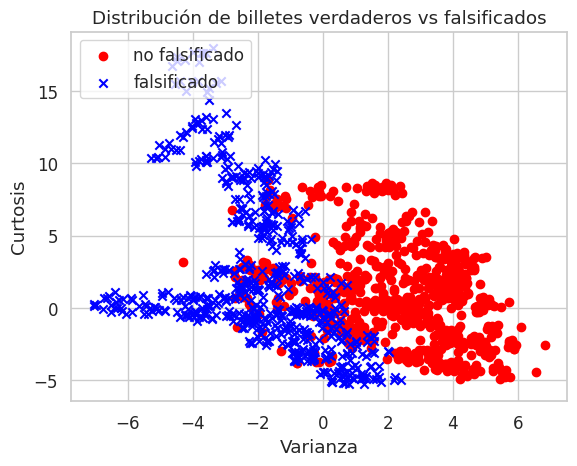

In [41]:
import matplotlib.pyplot as plt

# Filtrar por clase
X_no_falsificado = X[y == 0]
X_falsificado = X[y == 1]

# Graficar los datos
plt.scatter(X_no_falsificado.iloc[:, 0], X_no_falsificado.iloc[:, 1],
            color='red', marker='o', label='no falsificado')
plt.scatter(X_falsificado.iloc[:, 0], X_falsificado.iloc[:, 1],
            color='blue', marker='x', label='falsificado')

plt.xlabel('Varianza')
plt.ylabel('Curtosis')
plt.legend(loc='upper left')
plt.title('Distribución de billetes verdaderos vs falsificados')

plt.show()
